# RF & DSP Fundamentals — A Hands-On Notebook

This notebook walks through the signal processing chain of a radio transmission — from baseband audio through modulation, spectral analysis, and demodulation. Think of it as the math behind what happens when you key up your Baofeng.

## How This Notebook Works

If you're new to Jupyter (or coming back after years of MATLAB):

- **Cells** are the building blocks. Each gray box below is a cell. They're either **code** (Python) or **Markdown** (text/equations like this one).
- **Run a cell** with `Shift+Enter` (runs and advances) or `Ctrl+Enter` (runs and stays). Run them top-to-bottom the first time — later cells depend on earlier ones.
- **Kernel** = the Python process running behind the scenes. If things get weird, `Kernel → Restart & Run All` is your fresh start.
- **LaTeX** works in Markdown cells: `$f(t)$` for inline, `$$f(t)$$` for display math.
- **Variables persist** across cells within a session. Define `fs = 44100` in cell 3, and cell 15 can still use it.

---

## 0. Setup

Run this cell first to import everything we need.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, fft
from matplotlib.gridspec import GridSpec

# Nicer plots
plt.rcParams.update({
    'figure.figsize': (12, 4),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'lines.linewidth': 1.2,
})

# Utility: compute power spectral density via FFT
def power_spectrum(sig, fs, nfft=None):
    """Compute single-sided power spectrum in dB."""
    if nfft is None:
        nfft = len(sig)
    S = fft.fft(sig, n=nfft)
    S_mag = np.abs(S[:nfft // 2]) / nfft
    S_db = 20 * np.log10(S_mag + 1e-12)  # +eps to avoid log(0)
    freqs = np.linspace(0, fs / 2, nfft // 2)
    return freqs, S_db

print('Ready to go.')

Matplotlib is building the font cache; this may take a moment.


Ready to go.


---
## 1. Baseband Audio Signal

Before modulation, we need a signal to modulate. In a real radio, this is your voice — a complex waveform with energy roughly between 300 Hz and 3 kHz. We'll start simple with a single tone (sine wave), then combine a few to simulate something voice-like.

The general form of a sinusoid:

$$x(t) = A \cos(2\pi f t + \phi)$$

where $A$ is amplitude, $f$ is frequency in Hz, and $\phi$ is phase.

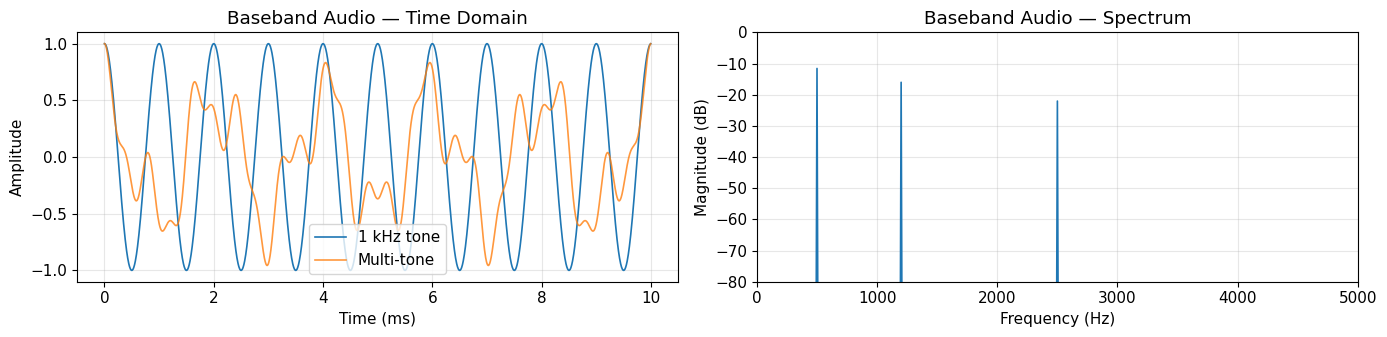

In [2]:
# Sampling parameters
fs = 200_000   # 200 kHz sample rate (high enough to represent UHF-like carriers)
duration = 0.05 # 50 ms window — enough to see modulation structure
t = np.arange(0, duration, 1/fs)

# Simple single-tone message signal (1 kHz tone, like a mic test)
f_msg = 1000  # 1 kHz
message = np.cos(2 * np.pi * f_msg * t)

# Multi-tone "voice-like" signal (sum of a few harmonics)
voice_like = (
    1.0 * np.cos(2 * np.pi * 500 * t) +
    0.6 * np.cos(2 * np.pi * 1200 * t) +
    0.3 * np.cos(2 * np.pi * 2500 * t)
)
voice_like /= np.max(np.abs(voice_like))  # normalize to [-1, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

# Time domain
axes[0].plot(t[:2000] * 1000, message[:2000], label='1 kHz tone')
axes[0].plot(t[:2000] * 1000, voice_like[:2000], label='Multi-tone', alpha=0.8)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Baseband Audio — Time Domain')
axes[0].legend()

# Frequency domain
freqs_v, psd_v = power_spectrum(voice_like, fs)
axes[1].plot(freqs_v, psd_v)
axes[1].set_xlim(0, 5000)
axes[1].set_ylim(-80, 0)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('Baseband Audio — Spectrum')

plt.tight_layout()
plt.show()

---
## 2. Amplitude Modulation (AM)

AM is the simplest modulation to understand, so we'll start here even though your Baofeng uses FM.

In AM, the **amplitude** of a high-frequency carrier varies in proportion to the message signal:

$$s_{AM}(t) = [1 + m \cdot x(t)] \cdot A_c \cos(2\pi f_c t)$$

where:
- $A_c$ = carrier amplitude
- $f_c$ = carrier frequency
- $m$ = modulation index (0 to 1 for normal AM; >1 = overmodulation)
- $x(t)$ = normalized message signal

The spectrum of an AM signal has three parts: the **carrier** at $f_c$, an **upper sideband** (USB) at $f_c + f_{msg}$, and a **lower sideband** (LSB) at $f_c - f_{msg}$. The sidebands are mirror images — each carries a copy of the message, which is why SSB (single-sideband) radios throw one away to save bandwidth.

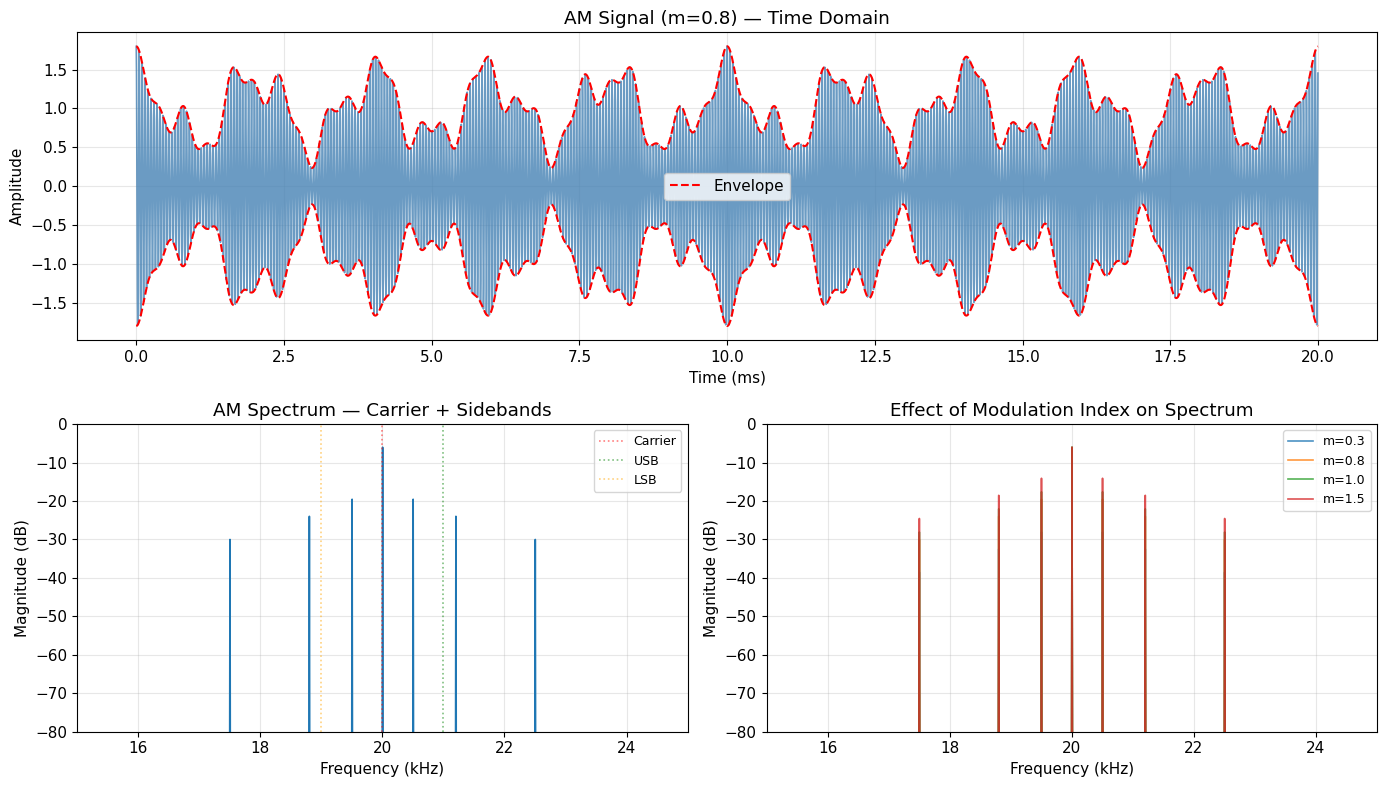

In [8]:
# AM modulation
f_carrier = 20_000  # 20 kHz carrier (low enough to visualize; real UHF would be ~462 MHz)
A_c = 1.0
m = 0.8  # modulation index — try changing this to 0.3, 1.0, 1.5

carrier = A_c * np.cos(2 * np.pi * f_carrier * t)
am_signal = (1 + m * voice_like) * carrier

fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 2, figure=fig)

# Time domain — zoomed in
ax1 = fig.add_subplot(gs[0, :])
samples_to_show = 4000
ax1.plot(t[:samples_to_show] * 1000, am_signal[:samples_to_show], color='steelblue', alpha=0.8)
# Envelope
env_upper = A_c * (1 + m * voice_like[:samples_to_show])
env_lower = -A_c * (1 + m * voice_like[:samples_to_show])
ax1.plot(t[:samples_to_show] * 1000, env_upper, 'r--', linewidth=1.5, label='Envelope')
ax1.plot(t[:samples_to_show] * 1000, env_lower, 'r--', linewidth=1.5)
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Amplitude')
ax1.set_title(f'AM Signal (m={m}) — Time Domain')
ax1.legend()

# Spectrum
ax2 = fig.add_subplot(gs[1, 0])
freqs_am, psd_am = power_spectrum(am_signal, fs, nfft=len(am_signal))
ax2.plot(freqs_am / 1000, psd_am)
ax2.set_xlim(15, 25)
ax2.set_ylim(-80, 0)
ax2.set_xlabel('Frequency (kHz)')
ax2.set_ylabel('Magnitude (dB)')
ax2.set_title('AM Spectrum — Carrier + Sidebands')
ax2.axvline(f_carrier/1000, color='red', linestyle=':', alpha=0.5, label='Carrier')
ax2.axvline((f_carrier + f_msg)/1000, color='green', linestyle=':', alpha=0.5, label='USB')
ax2.axvline((f_carrier - f_msg)/1000, color='orange', linestyle=':', alpha=0.5, label='LSB')
ax2.legend(fontsize=9)

# Overmodulation demo
ax3 = fig.add_subplot(gs[1, 1])
for mod_idx in [0.3, 0.8, 1.0, 1.5]:
    am_temp = (1 + mod_idx * voice_like) * carrier
    f_temp, p_temp = power_spectrum(am_temp, fs)
    ax3.plot(f_temp / 1000, p_temp, label=f'm={mod_idx}', alpha=0.8)
ax3.set_xlim(15, 25)
ax3.set_ylim(-80, 0)
ax3.set_xlabel('Frequency (kHz)')
ax3.set_ylabel('Magnitude (dB)')
ax3.set_title('Effect of Modulation Index on Spectrum')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

### Things to try

Go back and change `m` to different values:
- `m = 0.3` — shallow modulation, most power wasted in the carrier
- `m = 1.0` — 100% modulation, envelope just touches zero
- `m = 1.5` — **overmodulation**: the envelope goes negative, which causes distortion and splatter into adjacent channels

---

## 3. Frequency Modulation (FM) — What Your Baofeng Does

In FM, the carrier amplitude stays constant — all the information is in the **instantaneous frequency**:

$$s_{FM}(t) = A_c \cos\left(2\pi f_c t + 2\pi k_f \int_0^t m(\tau)\, d\tau \right)$$

where $k_f$ is the **frequency deviation sensitivity** (Hz per unit amplitude). The maximum frequency deviation is:

$$\Delta f = k_f \cdot \max|m(t)|$$

The **modulation index** for FM is:

$$\beta = \frac{\Delta f}{f_{msg}}$$

This is fundamentally different from AM's modulation index. For narrowband FM (NBFM) like GMRS:
- $\Delta f = \pm 2.5$ kHz (narrow) or $\pm 5$ kHz (wide)
- With a 1 kHz tone: $\beta = 2.5$ or $5$

**Carson's Rule** estimates the occupied bandwidth:

$$BW \approx 2(\Delta f + f_{msg})$$

For NBFM GMRS: $BW \approx 2(2500 + 3000) = 11$ kHz, which fits in a 12.5 kHz channel.

Modulation index β = 2.5
Carson's rule BW = 7.0 kHz


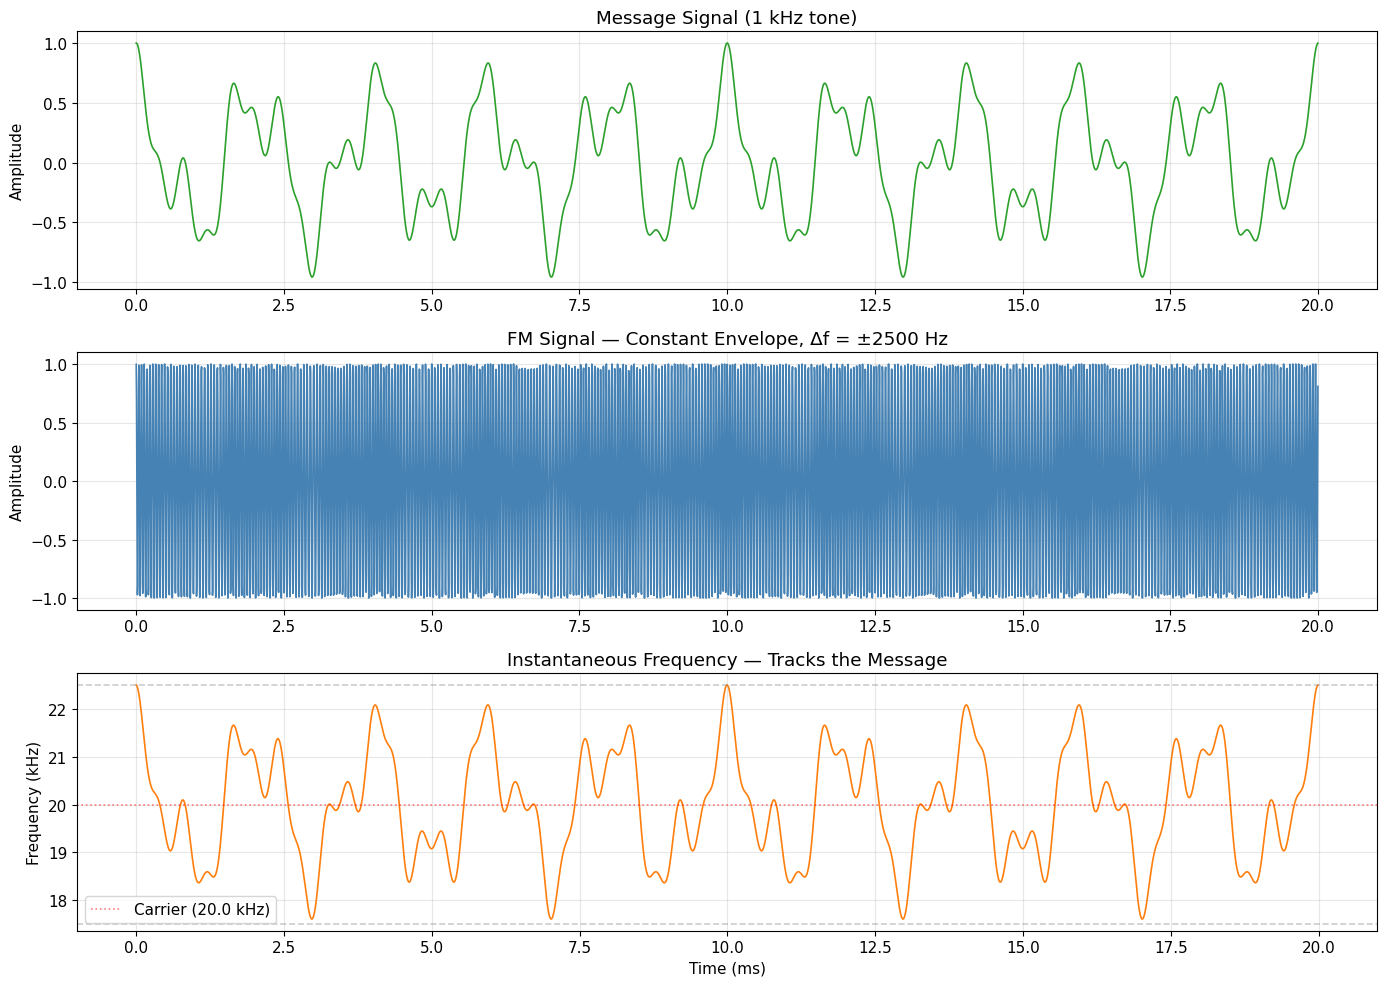

In [9]:
# FM modulation
f_carrier_fm = 20_000  # 20 kHz carrier for visualization
freq_dev = 2500        # ±2.5 kHz deviation (GMRS narrowband)
k_f = freq_dev         # since max|message| = 1

# The key: integrate the message signal to get phase
# cumulative_trapezoid integrates numerically; cumsum is the quick approximation
phase_integral = np.cumsum(voice_like) / fs  # numerical integration via cumulative sum
fm_signal = A_c * np.cos(2 * np.pi * f_carrier_fm * t + 2 * np.pi * k_f * phase_integral)

# Instantaneous frequency (derivative of phase)
inst_phase = 2 * np.pi * f_carrier_fm * t + 2 * np.pi * k_f * phase_integral
inst_freq = np.diff(inst_phase) / (2 * np.pi) * fs  # derivative → Hz

beta = freq_dev / f_msg
carson_bw = 2 * (freq_dev + f_msg)
print(f'Modulation index β = {beta:.1f}')
print(f"Carson's rule BW = {carson_bw/1000:.1f} kHz")

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Message signal
samples_show = 4000
axes[0].plot(t[:samples_show] * 1000, voice_like[:samples_show], color='tab:green')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('Message Signal (1 kHz tone)')

# FM waveform — notice constant amplitude, varying frequency
axes[1].plot(t[:samples_show] * 1000, fm_signal[:samples_show], color='steelblue')
axes[1].set_ylabel('Amplitude')
axes[1].set_title(f'FM Signal — Constant Envelope, Δf = ±{freq_dev} Hz')

# Instantaneous frequency — shows the frequency swinging with the message
axes[2].plot(t[:samples_show-1] * 1000, inst_freq[:samples_show-1] / 1000, color='tab:orange')
axes[2].axhline(f_carrier_fm/1000, color='red', linestyle=':', alpha=0.5, label=f'Carrier ({f_carrier_fm/1000} kHz)')
axes[2].axhline((f_carrier_fm + freq_dev)/1000, color='gray', linestyle='--', alpha=0.4)
axes[2].axhline((f_carrier_fm - freq_dev)/1000, color='gray', linestyle='--', alpha=0.4)
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Frequency (kHz)')
axes[2].set_title('Instantaneous Frequency — Tracks the Message')
axes[2].legend()

plt.tight_layout()
plt.show()

### Key observation

Look at the middle plot: the **amplitude never changes** (constant envelope). All the information is encoded in how tightly or loosely the oscillation cycles are packed together. When the message is at its positive peak, the carrier frequency increases (cycles get denser). When the message swings negative, the frequency decreases (cycles spread out).

This is why FM is resistant to amplitude noise — a lightning strike or ignition noise adds amplitude spikes, but since FM carries no information in amplitude, a limiter can clip those spikes right off before demodulation.

---

## 4. FM Spectrum and the Effect of Deviation

Unlike AM (which always has exactly 2 sidebands), FM produces an **infinite series** of sidebands spaced at multiples of $f_{msg}$ from the carrier. The amplitudes of these sidebands are given by **Bessel functions of the first kind**:

$$s_{FM}(t) = A_c \sum_{n=-\infty}^{\infty} J_n(\beta) \cos\left(2\pi (f_c + n f_{msg}) t\right)$$

where $J_n(\beta)$ is the $n$-th order Bessel function. Higher $\beta$ means more significant sidebands and a wider occupied bandwidth.

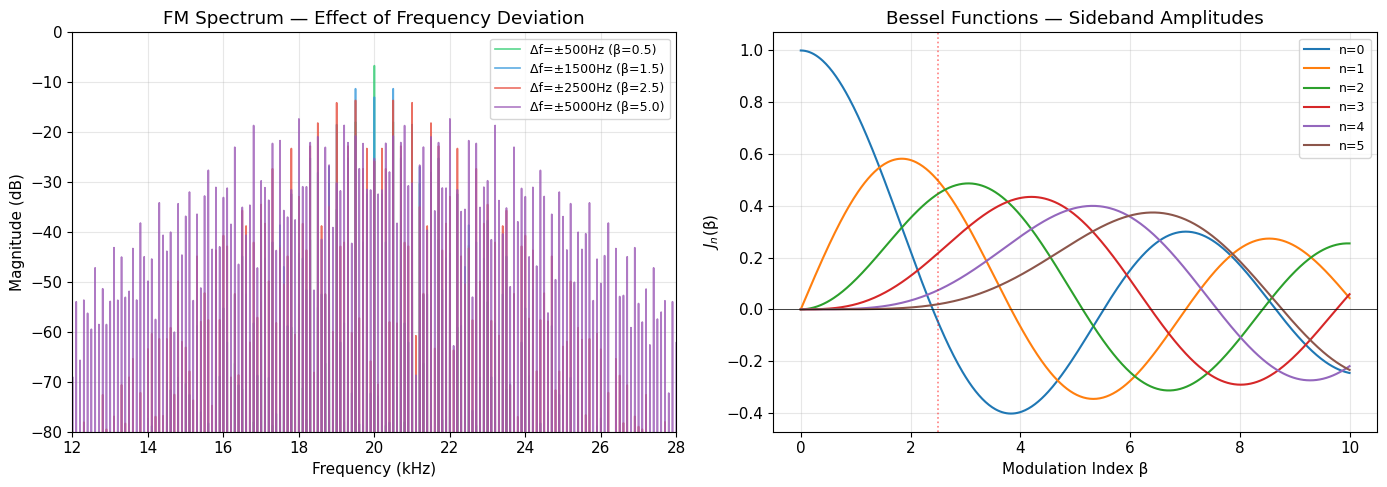


Bessel coefficients at β = 2.5 (GMRS narrowband):
  Carrier (n=0): J₀ = -0.0484  →  -26.3 dB
  Sideband n=1:  J_1 = +0.4971  →  -6.1 dB
  Sideband n=2:  J_2 = +0.4461  →  -7.0 dB
  Sideband n=3:  J_3 = +0.2166  →  -13.3 dB
  Sideband n=4:  J_4 = +0.0738  →  -22.6 dB
  Sideband n=5:  J_5 = +0.0195  →  -34.2 dB


In [10]:
from scipy.special import jv  # Bessel function of the first kind

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: FM spectrum for different deviation values
deviations = [500, 1500, 2500, 5000]  # Hz
colors = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6']

for dev, color in zip(deviations, colors):
    phase_int = np.cumsum(voice_like) / fs
    fm_temp = A_c * np.cos(2 * np.pi * f_carrier_fm * t + 2 * np.pi * dev * phase_int)
    freqs_fm, psd_fm = power_spectrum(fm_temp, fs)
    b = dev / f_msg
    axes[0].plot(freqs_fm/1000, psd_fm, color=color, label=f'Δf=±{dev}Hz (β={b:.1f})', alpha=0.8)

axes[0].set_xlim(12, 28)
axes[0].set_ylim(-80, 0)
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('FM Spectrum — Effect of Frequency Deviation')
axes[0].legend(fontsize=9)

# Right: Bessel function amplitudes (theoretical sideband levels)
beta_range = np.linspace(0, 10, 500)
for n in range(6):
    label = f'$J_{n}$(β)' if n < 4 else f'$J_{n}$(β)'
    axes[1].plot(beta_range, jv(n, beta_range), label=f'n={n}', linewidth=1.5)

axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_xlabel('Modulation Index β')
axes[1].set_ylabel('$J_n$(β)')
axes[1].set_title('Bessel Functions — Sideband Amplitudes')
axes[1].legend(fontsize=9)

# Mark the GMRS narrowband beta
axes[1].axvline(2.5, color='red', linestyle=':', alpha=0.5, label='GMRS NB (β=2.5)')

plt.tight_layout()
plt.show()

# Print Bessel coefficients for GMRS narrowband
print(f'\nBessel coefficients at β = 2.5 (GMRS narrowband):')
print(f'  Carrier (n=0): J₀ = {jv(0, 2.5):.4f}  →  {20*np.log10(abs(jv(0, 2.5))):.1f} dB')
for n in range(1, 6):
    val = jv(n, 2.5)
    db = 20*np.log10(abs(val)) if abs(val) > 1e-10 else -100
    print(f'  Sideband n={n}:  J_{n} = {val:+.4f}  →  {db:.1f} dB')

### What the Bessel functions tell us

Notice something wild in the Bessel plot: at certain values of $\beta$, the **carrier itself disappears** ($J_0 = 0$ at $\beta \approx 2.405$). All the power moves into sidebands. This is called **carrier null** and it's a real effect you can observe on a spectrum analyzer. GMRS narrowband at $\beta = 2.5$ is right near a carrier null — almost all the transmitted power is in the sidebands.

---

## 5. AM vs FM — Side by Side Comparison

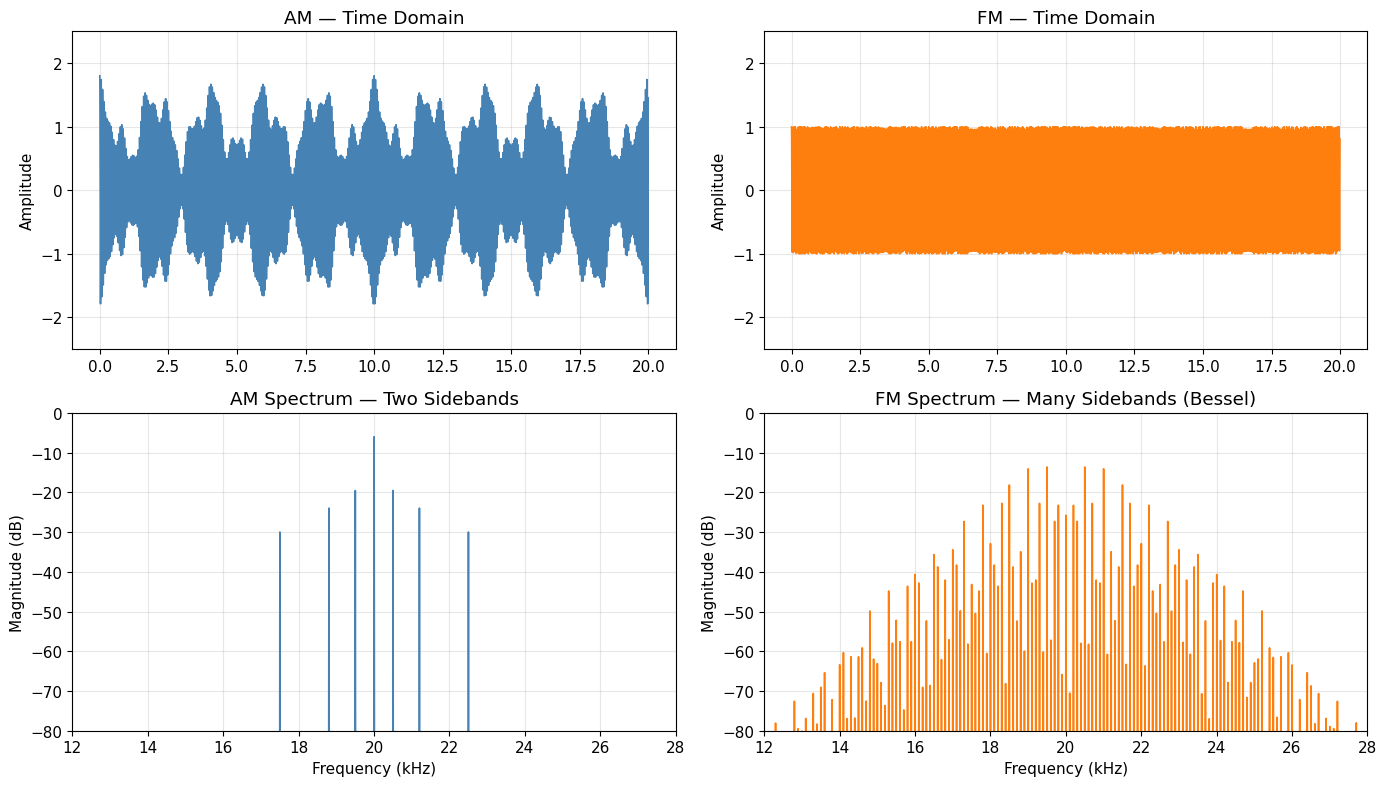

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

samples_show = 4000

# AM time domain
axes[0, 0].plot(t[:samples_show]*1000, am_signal[:samples_show], color='steelblue')
axes[0, 0].set_title('AM — Time Domain')
axes[0, 0].set_ylabel('Amplitude')
axes[0, 0].set_ylim(-2.5, 2.5)

# FM time domain
axes[0, 1].plot(t[:samples_show]*1000, fm_signal[:samples_show], color='tab:orange')
axes[0, 1].set_title('FM — Time Domain')
axes[0, 1].set_ylabel('Amplitude')
axes[0, 1].set_ylim(-2.5, 2.5)

# AM spectrum
freqs_am, psd_am = power_spectrum(am_signal, fs)
axes[1, 0].plot(freqs_am/1000, psd_am, color='steelblue')
axes[1, 0].set_xlim(12, 28)
axes[1, 0].set_ylim(-80, 0)
axes[1, 0].set_xlabel('Frequency (kHz)')
axes[1, 0].set_ylabel('Magnitude (dB)')
axes[1, 0].set_title('AM Spectrum — Two Sidebands')

# FM spectrum
freqs_fm, psd_fm = power_spectrum(fm_signal, fs)
axes[1, 1].plot(freqs_fm/1000, psd_fm, color='tab:orange')
axes[1, 1].set_xlim(12, 28)
axes[1, 1].set_ylim(-80, 0)
axes[1, 1].set_xlabel('Frequency (kHz)')
axes[1, 1].set_ylabel('Magnitude (dB)')
axes[1, 1].set_title('FM Spectrum — Many Sidebands (Bessel)')

plt.tight_layout()
plt.show()

The visual difference is striking:
- **AM**: amplitude wobbles, frequency is constant. Spectrum is clean — one carrier spike, two sideband spikes.
- **FM**: amplitude is rock-solid, frequency wobbles. Spectrum spreads out across multiple Bessel sidebands.

---

## 6. FM Demodulation

On the receive side, we need to convert frequency variations back into amplitude variations. One common approach: **differentiate the signal** (frequency is the derivative of phase), then take the **envelope**.

A simpler practical method: use the **arctan discriminator**, which computes the instantaneous phase via `atan2(Q, I)` on the analytic signal, then differentiates. This is what SDR software typically does.

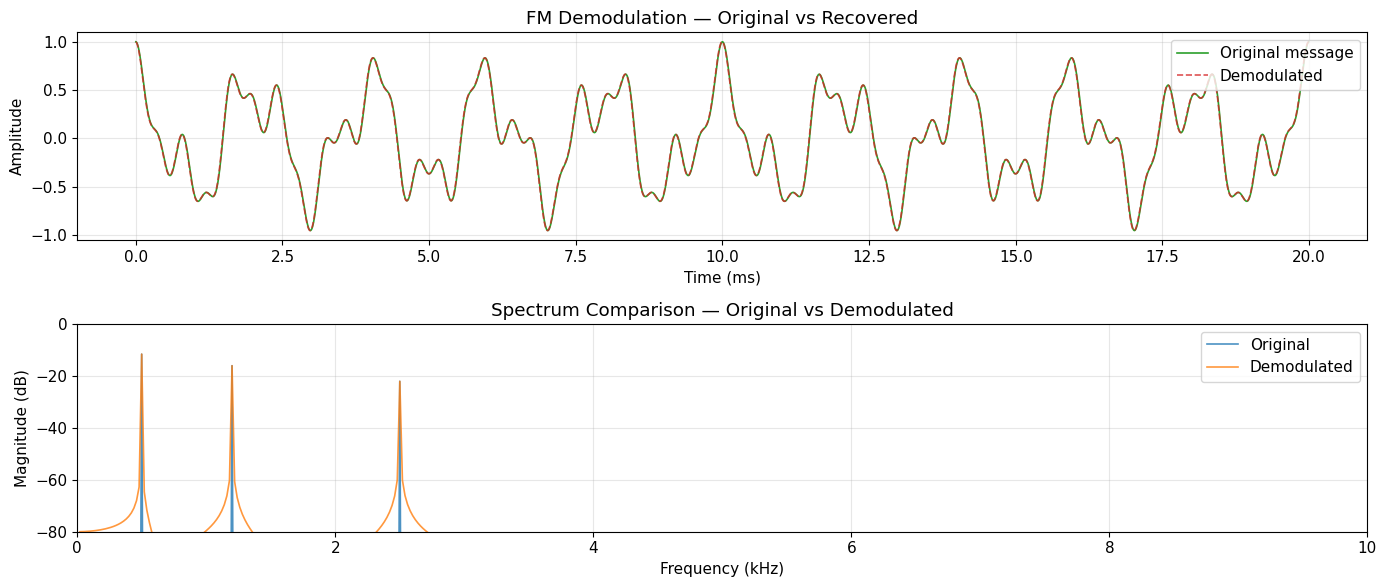

In [12]:
from scipy.signal import hilbert

# Generate analytic (complex) signal using Hilbert transform
analytic = hilbert(fm_signal)

# Extract instantaneous phase
inst_phase_demod = np.unwrap(np.angle(analytic))

# Differentiate phase to get instantaneous frequency → this IS the demodulated audio
demod_raw = np.diff(inst_phase_demod) * fs / (2 * np.pi)

# Remove carrier offset and normalize
demod = demod_raw - np.mean(demod_raw)
demod = demod / np.max(np.abs(demod))

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

samples_show = 4000
axes[0].plot(t[:samples_show]*1000, voice_like[:samples_show], color='tab:green', label='Original message')
axes[0].plot(t[:samples_show]*1000, demod[:samples_show], color='tab:red', linestyle='--', label='Demodulated', alpha=0.8)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Amplitude')
axes[0].set_title('FM Demodulation — Original vs Recovered')
axes[0].legend()

# Spectrum comparison
freqs_orig, psd_orig = power_spectrum(voice_like, fs)
freqs_demod, psd_demod = power_spectrum(demod, fs)
axes[1].plot(freqs_orig/1000, psd_orig, label='Original', alpha=0.8)
axes[1].plot(freqs_demod/1000, psd_demod, label='Demodulated', alpha=0.8)
axes[1].set_xlim(0, 10)
axes[1].set_ylim(-80, 0)
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('Spectrum Comparison — Original vs Demodulated')
axes[1].legend()

plt.tight_layout()
plt.show()

The recovered signal should overlay almost perfectly with the original. In a real receiver with noise, the high-frequency portion of the demodulated spectrum would show elevated noise — this is the **FM noise triangle** characteristic, which is why FM uses pre-emphasis/de-emphasis to compensate.

---

## 7. CTCSS (PL Tone) — Tone Squelch

Your Baofeng transmits a continuous sub-audible tone alongside your voice. Let's see what that looks like in the frequency domain.

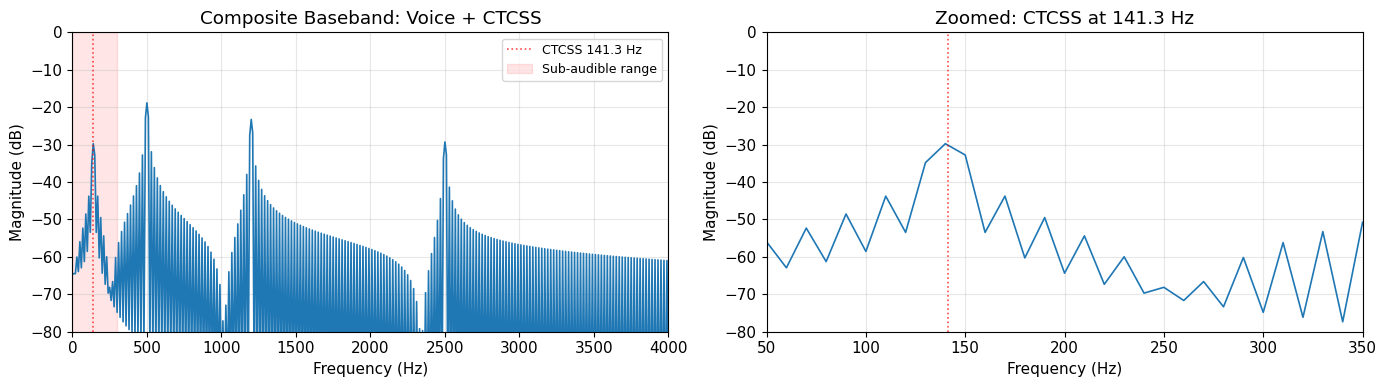

The CTCSS tone at 141.3 Hz sits below the 300 Hz voice band.
The receiver uses a narrow bandpass filter (or digital correlator) to detect it.
A high-pass filter at ~300 Hz strips it before audio reaches the speaker.


In [13]:
# Simulate voice + CTCSS tone
ctcss_freq = 141.3  # Hz — a common PL tone
ctcss_amplitude = 0.15  # ~15% of voice level (subtle)

# Composite baseband signal: voice + CTCSS
ctcss_tone = ctcss_amplitude * np.cos(2 * np.pi * ctcss_freq * t)
composite = voice_like + ctcss_tone
composite /= np.max(np.abs(composite))  # normalize

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Spectrum — full view
freqs_c, psd_c = power_spectrum(composite, fs, nfft=len(composite)*2)
axes[0].plot(freqs_c, psd_c)
axes[0].set_xlim(0, 4000)
axes[0].set_ylim(-80, 0)
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_ylabel('Magnitude (dB)')
axes[0].set_title('Composite Baseband: Voice + CTCSS')
axes[0].axvline(ctcss_freq, color='red', linestyle=':', alpha=0.7, label=f'CTCSS {ctcss_freq} Hz')
axes[0].axvspan(0, 300, alpha=0.1, color='red', label='Sub-audible range')
axes[0].legend(fontsize=9)

# Spectrum — zoomed into CTCSS range
axes[1].plot(freqs_c, psd_c)
axes[1].set_xlim(50, 350)
axes[1].set_ylim(-80, 0)
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title(f'Zoomed: CTCSS at {ctcss_freq} Hz')
axes[1].axvline(ctcss_freq, color='red', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

print(f'The CTCSS tone at {ctcss_freq} Hz sits below the 300 Hz voice band.')
print('The receiver uses a narrow bandpass filter (or digital correlator) to detect it.')
print('A high-pass filter at ~300 Hz strips it before audio reaches the speaker.')

---
## 8. Filter Design — Receive Chain Bandpass Filter

A receiver's front end needs to select only the desired bandwidth while rejecting everything else. Let's design a bandpass filter like you'd find in a receiver's IF stage.

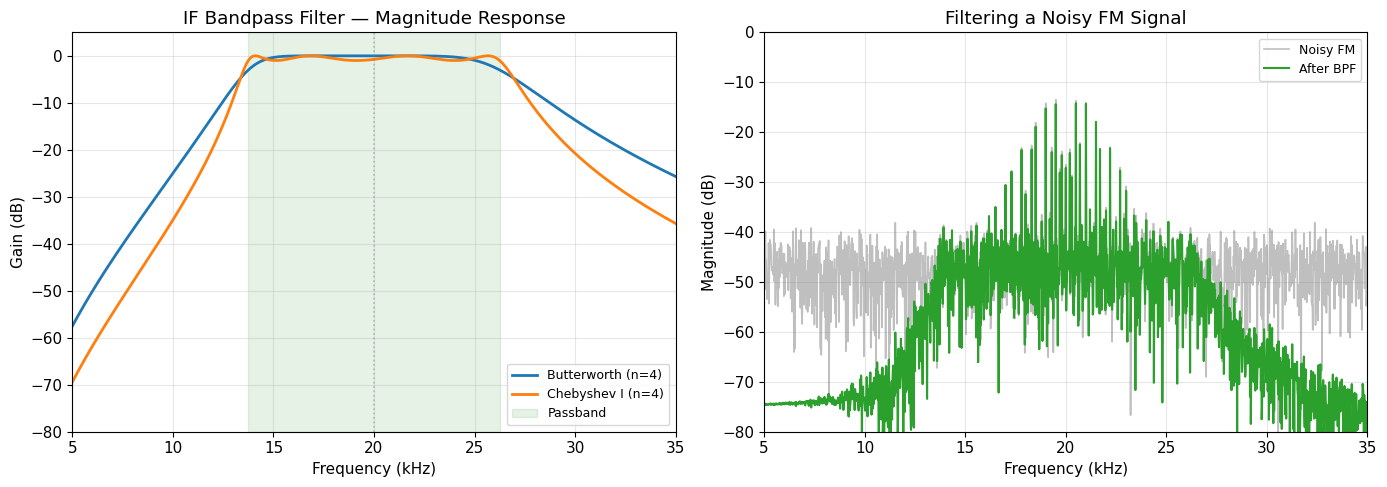

In [14]:
# Design a bandpass filter for NBFM channel (12.5 kHz wide, centered at 20 kHz IF)
f_center = 20_000  # IF center frequency
channel_bw = 12_500  # 12.5 kHz channel
f_low = f_center - channel_bw / 2
f_high = f_center + channel_bw / 2

# Butterworth bandpass filter (4th order)
order = 4
sos_butter = signal.butter(order, [f_low, f_high], btype='band', fs=fs, output='sos')

# Chebyshev Type I (sharper rolloff, 1 dB ripple)
sos_cheby = signal.cheby1(order, 1, [f_low, f_high], btype='band', fs=fs, output='sos')

# Frequency response
w_b, h_b = signal.sosfreqz(sos_butter, worN=8192, fs=fs)
w_c, h_c = signal.sosfreqz(sos_cheby, worN=8192, fs=fs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Magnitude response
axes[0].plot(w_b/1000, 20*np.log10(np.abs(h_b) + 1e-12), label=f'Butterworth (n={order})', linewidth=2)
axes[0].plot(w_c/1000, 20*np.log10(np.abs(h_c) + 1e-12), label=f'Chebyshev I (n={order})', linewidth=2)
axes[0].set_xlim(5, 35)
axes[0].set_ylim(-80, 5)
axes[0].set_xlabel('Frequency (kHz)')
axes[0].set_ylabel('Gain (dB)')
axes[0].set_title('IF Bandpass Filter — Magnitude Response')
axes[0].axvline(f_center/1000, color='gray', linestyle=':', alpha=0.5)
axes[0].axvspan(f_low/1000, f_high/1000, alpha=0.1, color='green', label='Passband')
axes[0].legend(fontsize=9)

# Apply filter to noisy FM signal
np.random.seed(42)
noise = 0.5 * np.random.randn(len(fm_signal))
noisy_fm = fm_signal + noise
filtered_fm = signal.sosfilt(sos_cheby, noisy_fm)

freqs_noisy, psd_noisy = power_spectrum(noisy_fm, fs)
freqs_filt, psd_filt = power_spectrum(filtered_fm, fs)

axes[1].plot(freqs_noisy/1000, psd_noisy, alpha=0.5, label='Noisy FM', color='gray')
axes[1].plot(freqs_filt/1000, psd_filt, label='After BPF', color='tab:green', linewidth=1.5)
axes[1].set_xlim(5, 35)
axes[1].set_ylim(-80, 0)
axes[1].set_xlabel('Frequency (kHz)')
axes[1].set_ylabel('Magnitude (dB)')
axes[1].set_title('Filtering a Noisy FM Signal')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### Filter tradeoffs

- **Butterworth**: maximally flat passband, gentle rolloff. Good if you don't want any amplitude ripple.
- **Chebyshev Type I**: allows passband ripple in exchange for steeper rolloff. Better adjacent-channel rejection.
- **Crystal / ceramic filters** in real radios achieve extremely sharp rolloff at the IF frequency — much better than what you'd get with a few analog poles.

---

## 9. Spectrogram — Time-Frequency View

A spectrogram shows how the frequency content evolves over time. This is what you see in waterfall displays on SDR software. It uses the **Short-Time Fourier Transform (STFT)** — basically chopping the signal into overlapping windows and computing an FFT on each.

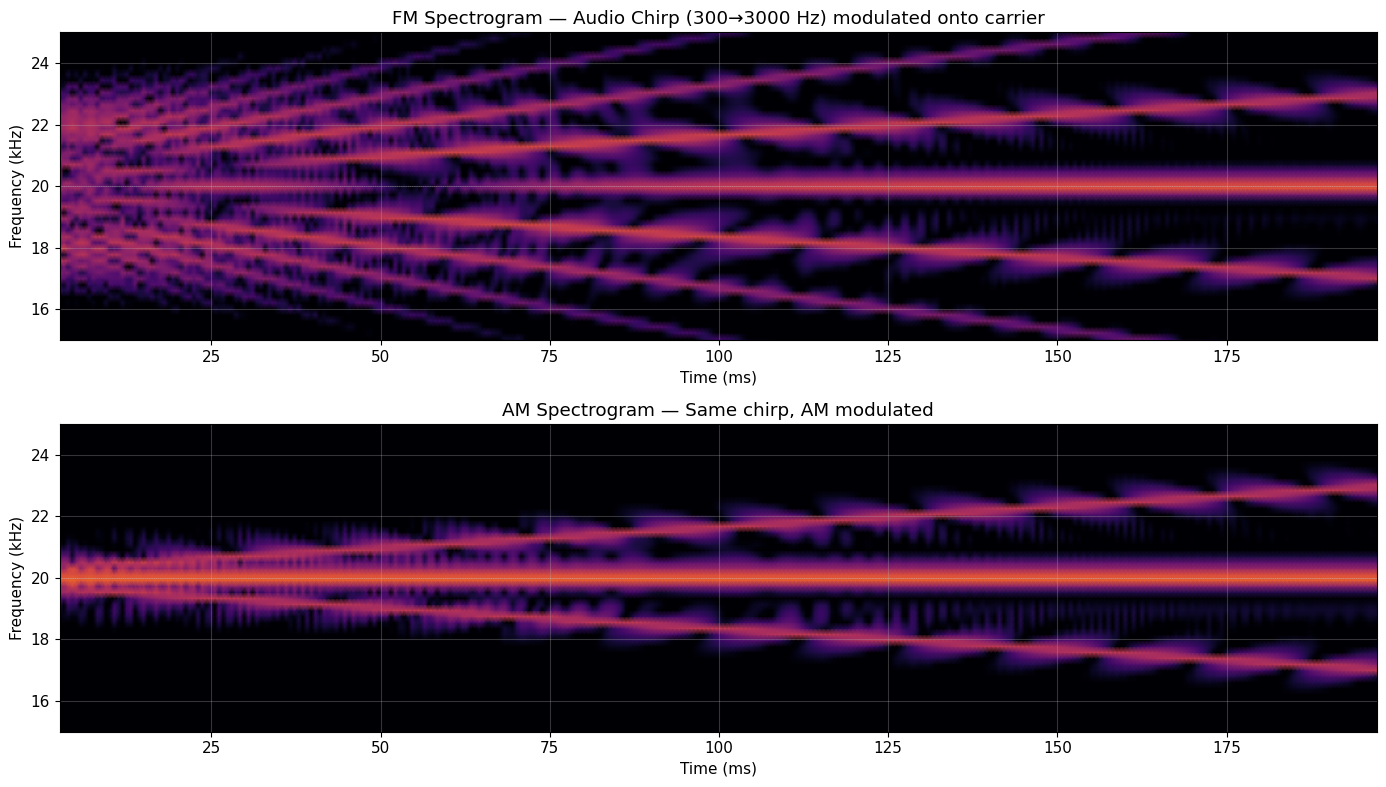

In [15]:
# Create a longer signal with a chirped (sweeping) audio tone
dur_long = 0.2  # 200ms
t_long = np.arange(0, dur_long, 1/fs)

# Chirp: audio frequency sweeps from 300 Hz to 3000 Hz
chirp_msg = signal.chirp(t_long, f0=300, f1=3000, t1=dur_long, method='linear')

# FM modulate the chirp
phase_chirp = np.cumsum(chirp_msg) / fs
fm_chirp = np.cos(2 * np.pi * f_carrier_fm * t_long + 2 * np.pi * freq_dev * phase_chirp)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Spectrogram of the FM chirp signal
f_spec, t_spec, Sxx = signal.spectrogram(fm_chirp, fs, nperseg=1024, noverlap=900)
axes[0].pcolormesh(t_spec*1000, f_spec/1000, 10*np.log10(Sxx + 1e-12), 
                    shading='gouraud', cmap='inferno', vmin=-60, vmax=-10)
axes[0].set_ylim(15, 25)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Frequency (kHz)')
axes[0].set_title('FM Spectrogram — Audio Chirp (300→3000 Hz) modulated onto carrier')
axes[0].axhline(f_carrier_fm/1000, color='white', linestyle=':', alpha=0.3, linewidth=0.5)

# For comparison: AM spectrogram of same chirp
am_chirp = (1 + 0.8 * chirp_msg) * np.cos(2 * np.pi * f_carrier_fm * t_long)
f_spec_am, t_spec_am, Sxx_am = signal.spectrogram(am_chirp, fs, nperseg=1024, noverlap=900)
axes[1].pcolormesh(t_spec_am*1000, f_spec_am/1000, 10*np.log10(Sxx_am + 1e-12), 
                    shading='gouraud', cmap='inferno', vmin=-60, vmax=-10)
axes[1].set_ylim(15, 25)
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Frequency (kHz)')
axes[1].set_title('AM Spectrogram — Same chirp, AM modulated')
axes[1].axhline(f_carrier_fm/1000, color='white', linestyle=':', alpha=0.3, linewidth=0.5)

plt.tight_layout()
plt.show()

The FM spectrogram shows the signal "spreading" around the carrier as the audio frequency increases — wider spectral occupancy tracks the rising deviation demands of the chirp. The AM spectrogram shows clean symmetric sidebands sweeping away from the carrier.

---

## 10. Free Space Path Loss

Finally, let's model what happens between the antennas. The Friis transmission equation gives received power:

$$P_r = P_t G_t G_r \left(\frac{\lambda}{4\pi d}\right)^2$$

In dB form:

$$FSPL_{dB} = 20\log_{10}(d) + 20\log_{10}(f) + 32.44$$

where $d$ is in km and $f$ in MHz.

Baofeng GMRS Link Budget:
  TX Power: 37.0 dBm (5.0W)
  EIRP: 35.0 dBm
  Max theoretical range (free space): 50.0 km
  Usable range (12dB margin): 50.0 km
  (Real-world with obstructions: maybe 1/5 to 1/3 of this)


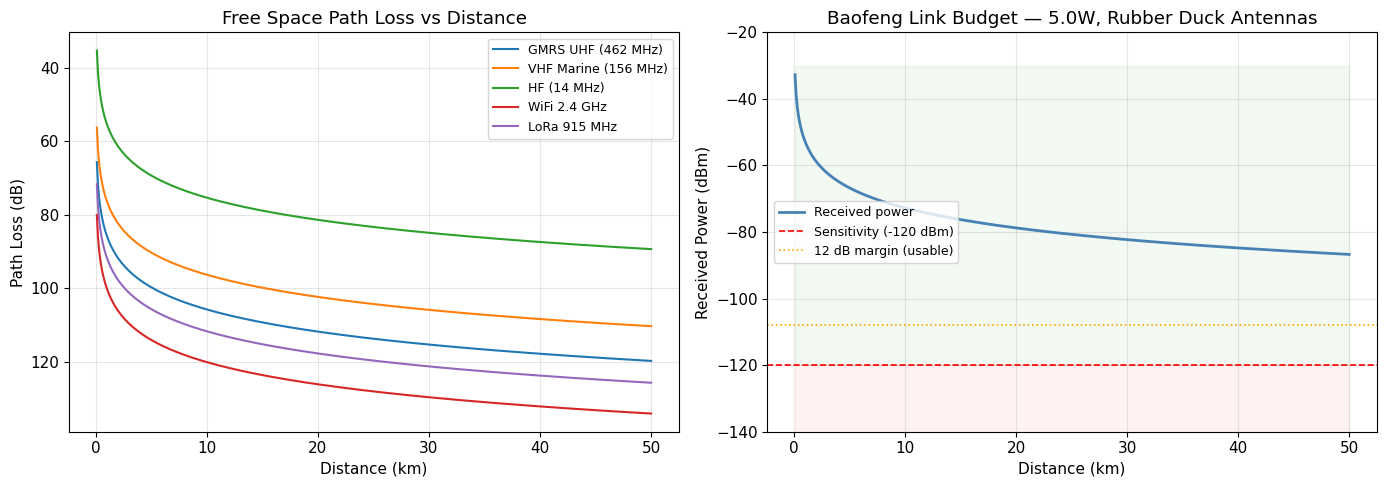

In [16]:
def fspl_db(d_km, f_mhz):
    """Free-space path loss in dB."""
    return 20 * np.log10(d_km) + 20 * np.log10(f_mhz) + 32.44

distances = np.linspace(0.1, 50, 500)  # 100m to 50km

# GMRS frequencies and common comparisons
freqs_compare = {
    'GMRS UHF (462 MHz)': 462,
    'VHF Marine (156 MHz)': 156,
    'HF (14 MHz)': 14,
    'WiFi 2.4 GHz': 2400,
    'LoRa 915 MHz': 915,
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, freq in freqs_compare.items():
    axes[0].plot(distances, fspl_db(distances, freq), label=label, linewidth=1.5)

axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Path Loss (dB)')
axes[0].set_title('Free Space Path Loss vs Distance')
axes[0].legend(fontsize=9)
axes[0].invert_yaxis()

# Link budget for a Baofeng-to-Baofeng GMRS link
tx_power_w = 5.0
tx_power_dbm = 10 * np.log10(tx_power_w * 1000)  # ≈ 37 dBm
tx_antenna_gain = -2   # dBi (rubber duck is negative gain!)
rx_antenna_gain = -2   # dBi
rx_sensitivity = -120  # dBm (typical for FM)
cable_loss = 0         # direct connect

# Effective Isotropic Radiated Power
eirp = tx_power_dbm + tx_antenna_gain

# Received power vs distance
rx_power = eirp + rx_antenna_gain - fspl_db(distances, 462)

axes[1].plot(distances, rx_power, color='steelblue', linewidth=2, label='Received power')
axes[1].axhline(rx_sensitivity, color='red', linestyle='--', label=f'Sensitivity ({rx_sensitivity} dBm)')
axes[1].axhline(rx_sensitivity + 12, color='orange', linestyle=':', label='12 dB margin (usable)')
axes[1].fill_between(distances, rx_sensitivity, -30, alpha=0.05, color='green')
axes[1].fill_between(distances, -160, rx_sensitivity, alpha=0.05, color='red')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Received Power (dBm)')
axes[1].set_title(f'Baofeng Link Budget — {tx_power_w}W, Rubber Duck Antennas')
axes[1].set_ylim(-140, -20)
axes[1].legend(fontsize=9)

# Find max range
max_range_idx = np.argmin(np.abs(rx_power - rx_sensitivity))
max_range_usable_idx = np.argmin(np.abs(rx_power - (rx_sensitivity + 12)))
print(f'Baofeng GMRS Link Budget:')
print(f'  TX Power: {tx_power_dbm:.1f} dBm ({tx_power_w}W)')
print(f'  EIRP: {eirp:.1f} dBm')
print(f'  Max theoretical range (free space): {distances[max_range_idx]:.1f} km')
print(f'  Usable range (12dB margin): {distances[max_range_usable_idx]:.1f} km')
print(f'  (Real-world with obstructions: maybe 1/5 to 1/3 of this)')

plt.tight_layout()
plt.show()

---
## Next Steps

Some things to explore from here:

- **`ipywidgets`**: Add interactive sliders to change modulation index, deviation, filter order in real-time
- **`scikit-dsp-comm`**: Has pre-built FM mod/demod, PLL simulations, eye diagrams
- **RTL-SDR + `pyrtlsdr`**: Capture real off-air signals and run them through this same processing
- **GNU Radio**: Visual flowgraph-based signal processing, can connect to real hardware
- **Add noise**: Model different SNR levels and see how FM's noise performance compares to AM
- **Pre-emphasis / de-emphasis**: Implement the 6 dB/octave boost and cut that FM land-mobile uses